# Week 5 Lab Notebook #2: Building Neural Network Components
## From Tensors to Layers

### Learning Objectives
By the end of this notebook, you will:
- Understand what neural network layers actually do
- Build a linear layer from scratch to see how it works
- Use PyTorch's built-in layers
- Connect multiple layers together
- Understand activation functions

---

In [1]:
# Import everything we need
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)

print("Ready to build neural networks")

Ready to build neural networks


## Part 1: What is a Neural Network Layer?

A neural network layer is basically a mathematical function that:
1. Takes input data (as a tensor)
2. Multiplies it by weights (learnable parameters)
3. Adds a bias (another learnable parameter)
4. Outputs transformed data

### The Math (simplified)
```
output = input × weights + bias
```

Let's build this from scratch to understand it!

## Part 2: Building a Linear Layer from Scratch

Before using PyTorch's layers, let's build our own to see what's happening inside:

In [2]:
# Step 1: Create a simple linear layer manually
# Let's say we have 3 input features and want 2 output features

# Input: Imagine we have data with 3 features (e.g., height, weight, age)
input_features = 3
output_features = 2

# Weights: Random numbers that will be learned during training
# Shape: (input_features, output_features)
weights = torch.randn(input_features, output_features)
print("Weights shape:", weights.shape)
print("Weights:")
print(weights)
print()

# Bias: One value for each output
bias = torch.randn(output_features)
print("Bias shape:", bias.shape)
print("Bias:", bias)

Weights shape: torch.Size([3, 2])
Weights:
tensor([[ 0.3367,  0.1288],
        [ 0.2345,  0.2303],
        [-1.1229, -0.1863]])

Bias shape: torch.Size([2])
Bias: tensor([ 2.2082, -0.6380])


In [3]:
# Step 2: Use our manual layer
# Create some example input data (batch_size=4, features=3)
# Think of this as 4 samples, each with 3 features
batch_size = 4
input_data = torch.randn(batch_size, input_features)

print("Input shape:", input_data.shape)
print("Input data:")
print(input_data)
print()

# Apply our layer: output = input @ weights + bias
output = input_data @ weights + bias

print("Output shape:", output.shape)
print("Output data:")
print(output)
print("\nWe transformed 3 features into 2 features!")

Input shape: torch.Size([4, 3])
Input data:
tensor([[ 0.4617,  0.2674,  0.5349],
        [ 0.8094,  1.1103, -1.6898],
        [-0.9890,  0.9580,  1.3221],
        [ 0.8172, -0.7658, -0.7506]])

Output shape: torch.Size([4, 2])
Output data:
tensor([[ 1.8257, -0.6166],
        [ 4.6384,  0.0368],
        [ 0.6153, -0.7911],
        [ 3.1466, -0.5693]])

We transformed 3 features into 2 features!


### Your Turn: Exercise 2.1
Create a manual layer that:
1. Takes 5 input features
2. Outputs 3 features
3. Test it with a batch of 2 samples

In [4]:
# Your code here:
# Define dimensions
my_input_features = 5
my_output_features = 3
my_batch_size = 2

# Create weights and bias
my_weights = torch.randn(my_input_features, my_output_features) 
my_bias = torch.randn(my_output_features)

# Create input data and apply transformation
my_input = torch.randn(my_batch_size, my_input_features)
my_output = my_input @ my_weights + my_bias 

print(f"Transformed shape: {my_input.shape} → {my_output.shape}")

Transformed shape: torch.Size([2, 5]) → torch.Size([2, 3])


---

## Part 3: Using PyTorch's Linear Layer

Now let's use PyTorch's built-in `nn.Linear` which does exactly what we just did, but with extra features!

In [6]:
# Create a linear layer the PyTorch way
# nn.Linear(input_features, output_features)
layer = nn.Linear(3, 2)

print("Layer:", layer)
print("\nLayer's weights shape:", layer.weight.shape)
print("Layer's weights:")
print(layer.weight)
print("\nLayer's bias shape:", layer.bias.shape)
print("Layer's bias:", layer.bias)

# Note: PyTorch stores weights as (output_features, input_features) -> transposed!

Layer: Linear(in_features=3, out_features=2, bias=True)

Layer's weights shape: torch.Size([2, 3])
Layer's weights:
Parameter containing:
tensor([[ 0.0135, -0.3944, -0.4898],
        [-0.3179, -0.5053, -0.3676]], requires_grad=True)

Layer's bias shape: torch.Size([2])
Layer's bias: Parameter containing:
tensor([0.5771, 0.1090], requires_grad=True)


In [8]:
# Use the PyTorch layer
input_data = torch.randn(4, 3)  # 4 samples, 3 features

# Forward pass - just call the layer like a function!
output = layer(input_data)

print("Input shape:", input_data.shape)
print("Output shape:", output.shape)
print("\nOutput:")
print(output)

Input shape: torch.Size([4, 3])
Output shape: torch.Size([4, 2])

Output:
tensor([[ 1.9854,  1.3500],
        [ 0.4499,  0.3471],
        [ 1.2633,  0.6666],
        [ 0.0390, -0.2313]], grad_fn=<AddmmBackward0>)


---

## Part 4: Activation Functions

Linear layers alone can only learn linear patterns. **Activation functions** add non-linearity, allowing neural networks to learn complex patterns!

Common activation functions:
- **ReLU**: Replaces negative values with 0
- **Sigmoid**: Squashes values between 0 and 1
- **Tanh**: Squashes values between -1 and 1

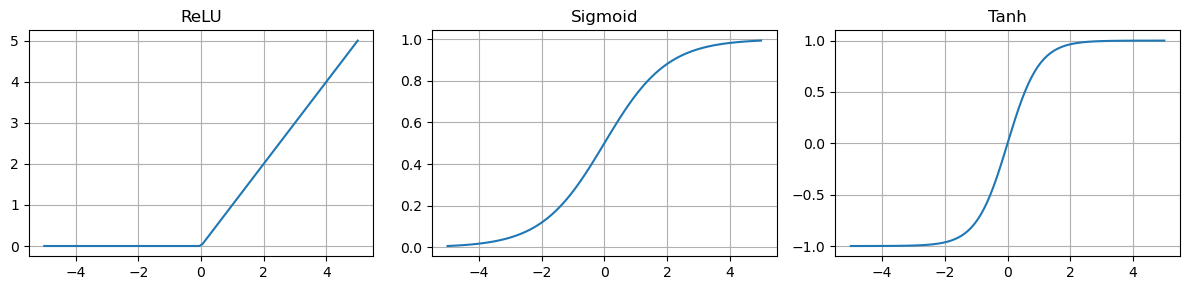

ReLU: Negative → 0, Positive → unchanged
Sigmoid: Everything → between 0 and 1
Tanh: Everything → between -1 and 1


In [12]:
# Let's visualize activation functions
x = torch.linspace(-5, 5, 100)

# ReLU
relu = nn.ReLU()
y_relu = relu(x)

# Sigmoid 
sigmoid = nn.Sigmoid()
y_sigmoid = sigmoid(x)

# Tanh
tanh = nn.Tanh()
y_tanh = tanh(x)

# Plot them
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].plot(x, y_relu)
axes[0].set_title('ReLU')
axes[0].grid(True)

axes[1].plot(x, y_sigmoid)
axes[1].set_title('Sigmoid')
axes[1].grid(True)

axes[2].plot(x, y_tanh)
axes[2].set_title('Tanh')
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("ReLU: Negative → 0, Positive → unchanged")
print("Sigmoid: Everything → between 0 and 1")
print("Tanh: Everything → between -1 and 1")

In [14]:
# See activation functions in action
test_values = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])

print("Original values:", test_values)
print("After ReLU:", relu(test_values))
print("After Sigmoid:", sigmoid(test_values))
print("After Tanh:", tanh(test_values))

Original values: tensor([-2., -1.,  0.,  1.,  2.])
After ReLU: tensor([0., 0., 0., 1., 2.])
After Sigmoid: tensor([0.1192, 0.2689, 0.5000, 0.7311, 0.8808])
After Tanh: tensor([-0.9640, -0.7616,  0.0000,  0.7616,  0.9640])


### Your Turn: Exercise 4.1
1. Create some data with negative and positive values
2. Apply ReLU activation
3. Observe what happens to negative values

In [15]:
# Your code here:
# Create data with mix of positive and negative
my_data = torch.tensor([-2.0, 3.0, 0.0, 6.0, 3.0, -0.8])

# Create and apply ReLU
my_relu = nn.ReLU()
my_result = my_relu(my_data)

print("Before ReLU:", my_data)
print("After ReLU:", my_result)

Before ReLU: tensor([-2.0000,  3.0000,  0.0000,  6.0000,  3.0000, -0.8000])
After ReLU: tensor([0., 3., 0., 6., 3., 0.])


---

## Part 5: Building a Multi-Layer Network

Real neural networks stack multiple layers with activations between them. Let's build one!

### Method 1: Manual Construction

In [16]:
# Build a 3-layer network manually
# Input (4) → Hidden (8) → Hidden (4) → Output (2)

# Define layers
layer1 = nn.Linear(4, 8)   # 4 inputs → 8 hidden
layer2 = nn.Linear(8, 4)   # 8 hidden → 4 hidden  
layer3 = nn.Linear(4, 2)   # 4 hidden → 2 outputs

# Define activations
activation = nn.ReLU()

# Create some input data
x = torch.randn(5, 4)  # 5 samples, 4 features

# Forward pass - apply each layer and activation
print("Input shape:", x.shape)

# Layer 1
x = layer1(x)
print("After layer 1:", x.shape)
x = activation(x)

# Layer 2
x = layer2(x)
print("After layer 2:", x.shape)
x = activation(x)

# Layer 3 (output layer - often no activation)
x = layer3(x)
print("Final output:", x.shape)

print("\nWe transformed 4 features → 2 outputs through hidden layers!")

Input shape: torch.Size([5, 4])
After layer 1: torch.Size([5, 8])
After layer 2: torch.Size([5, 4])
Final output: torch.Size([5, 2])

We transformed 4 features → 2 outputs through hidden layers!


### Method 2: Using nn.Sequential (Much Cleaner!)

In [19]:
# The same network using nn.Sequential
model = nn.Sequential(
    nn.Linear(4, 8),    # Input layer
    nn.ReLU(),          # Activation
    nn.Linear(8, 4),    # Hidden layer
    nn.ReLU(),          # Activation  
    nn.Linear(4, 2)     # Output layer
)

print("Our model:")
print(model)
print()

# Test it
input_data = torch.randn(5, 4)
output = model(input_data)

print(f"Input shape: {input_data.shape}")
print(f"Output shape: {output.shape}")

Our model:
Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=2, bias=True)
)

Input shape: torch.Size([5, 4])
Output shape: torch.Size([5, 2])


### Your Turn: Exercise 5.1
Build a neural network with:
1. Input size: 10
2. First hidden layer: 20 neurons
3. Second hidden layer: 15 neurons
4. Output size: 5
5. Use ReLU activations between layers

In [20]:
# Your code here:
my_model = nn.Sequential(
    nn.Linear(10, 20),
    nn.ReLU(),
    nn.Linear(20, 15),
    nn.ReLU(),
    nn.Linear(15, 5)
)

# Test your model
test_input = torch.randn(3, 10)  # 3 samples, 10 features
test_output = my_model(test_input)

print("Model structure:")
print(my_model)
print(f"\nTransformed: {test_input.shape} → {test_output.shape}")

Model structure:
Sequential(
  (0): Linear(in_features=10, out_features=20, bias=True)
  (1): ReLU()
  (2): Linear(in_features=20, out_features=15, bias=True)
  (3): ReLU()
  (4): Linear(in_features=15, out_features=5, bias=True)
)

Transformed: torch.Size([3, 10]) → torch.Size([3, 5])


---

## Part 6: Understanding Parameters

Neural networks learn by adjusting their parameters (weights and biases). Let's explore them:

In [21]:
# Create a simple model
simple_model = nn.Sequential(
    nn.Linear(3, 5),
    nn.ReLU(),
    nn.Linear(5, 2)
)

# Count parameters
total_params = 0
for name, param in simple_model.named_parameters():
    print(f"{name}: {param.shape}")
    total_params += param.numel()  # numel = number of elements

print(f"\nTotal parameters: {total_params}")

# Let's verify this calculation:
# Layer 1: 3×5 weights + 5 biases = 15 + 5 = 20
# Layer 2: 5×2 weights + 2 biases = 10 + 2 = 12
# Total: 20 + 12 = 32 ✓

0.weight: torch.Size([5, 3])
0.bias: torch.Size([5])
2.weight: torch.Size([2, 5])
2.bias: torch.Size([2])

Total parameters: 32


---

## Part 7: Practical Example - Building an MNIST-Ready Network

Let's build a network similar to what we'll use for MNIST digit classification:

In [22]:
# MNIST images are 28×28 = 784 pixels
# We want to classify into 10 digits (0-9)

mnist_model = nn.Sequential(
    nn.Flatten(),           # Flatten 28×28 image to 784 vector
    nn.Linear(784, 128),    # Input layer
    nn.ReLU(),
    nn.Linear(128, 64),     # Hidden layer
    nn.ReLU(),
    nn.Linear(64, 10)       # Output layer (10 classes)
)

print("MNIST Model:")
print(mnist_model)

# Test with fake MNIST data
fake_images = torch.randn(8, 1, 28, 28)  # 8 images, 1 channel, 28×28
output = mnist_model(fake_images)

print(f"\nInput shape: {fake_images.shape}")
print(f"Output shape: {output.shape}")
print("Output represents: probability scores for each of 10 digits")

MNIST Model:
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=10, bias=True)
)

Input shape: torch.Size([8, 1, 28, 28])
Output shape: torch.Size([8, 10])
Output represents: probability scores for each of 10 digits


In [27]:
# Let's see what the output looks like
# Take first image's predictions
first_output = output[0]
print("Raw output (logits):")
print(first_output)
print()

# Convert to probabilities using softmax
probabilities = torch.softmax(first_output, dim=0)
print("Probabilities (sum to 1):")
print(probabilities)
print(f"Sum: {probabilities.sum():.4f}")
print()

# Which digit has highest probability?
predicted_digit = torch.argmax(probabilities)
print(f"Predicted digit: {predicted_digit}")
print(f"Confidence: {probabilities[predicted_digit]:.2%}")

Raw output (logits):
tensor([-0.0738,  0.0652, -0.0938, -0.1069,  0.0777,  0.0609,  0.1916,  0.0409,
        -0.2894,  0.1383], grad_fn=<SelectBackward0>)

Probabilities (sum to 1):
tensor([0.0920, 0.1057, 0.0902, 0.0890, 0.1070, 0.1052, 0.1199, 0.1032, 0.0741,
        0.1137], grad_fn=<SoftmaxBackward0>)
Sum: 1.0000

Predicted digit: 6
Confidence: 11.99%


---

## Summary

### What You've Learned:
✓ **Linear layers** transform input features to output features  
✓ **Weights and biases** are the learnable parameters  
✓ **Activation functions** add non-linearity (ReLU, Sigmoid, Tanh)  
✓ **nn.Sequential** makes it easy to stack layers  
✓ **Parameters** are what the network learns during training  

### Key Insights:
1. **Each layer transforms data** - changing the number of features
2. **Activations are crucial** - without them, multiple layers = one layer
3. **More layers = more capacity** - but also more parameters to learn

### What's Next:
In the next notebook, we'll learn how to train these networks to actually learn from data!

---

## In-class Assignment 2/4 Part 2/3 (Part of Your Assessment Hand-In)

Create a function that:
1. Takes layer sizes as input (e.g., [784, 256, 128, 10])
2. Automatically builds a Sequential model with ReLU activations
3. Returns the model and total parameter count

In [42]:
def build_network(layer_sizes):
    """
    Build a neural network from a list of layer sizes.
    Example: [784, 256, 128, 10] creates a 3-layer network

    SO needs to find input layer, hidden layers and output
    - needs pairs from layer_sizes to create layers - 784, 256 then 256, 128 etc. = i, i+1 (index of layer_sizes)
    - append layer to end of layers[] list
    - needs ReLU activation at the end of each layer (append ReLU?)
    - add layers to nn.Sequential() model
    - then calculate parameters..
    """
    layers = [] #keeps layers in order [linear, relu, linear, relu, linear, etc.]
    for i in range(len(layer_sizes) - 1):
        input_features = layer_sizes[i]
        output_features = layer_sizes[i + 1]

        #linear layer - @ weights + bias:
        layers.append(nn.Linear(input_features, output_features)) 
        #creates layer[i](batch_size, input_features) into (batch_size, output_features)

        if i < len(layer_sizes) - 2: #not after output
            layers.append(nn.ReLU()) 

    model = nn.Sequential(*layers) #unpacking layers as own arguments

    #calculating and adding layer etc. for amount of parameters
    # params = 0 

    # for name, param in model.named_parameters(): #can also do .parameters() for only tensors
    #     print(f"{name} : {param.shape}") #shows which layer and their weight and bias
    #     params += param.numel() #adding amount of numbers in each tensor to get total

    #OR just for calculating amount of params
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)


    return model, params

# Test your function
model, params = build_network([784, 256, 128, 10])
print(f"\n{model}")
print(f"\nTotal parameters: {params}")

#bias size will always be output_features bc there'll always be a bias for each feature


Sequential(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 235146
